# Flight Delay Prediction — Ensemble Methods

**Author:** Nurgul Kalymbet  
**Dataset:** [2015 Flight Delays and Cancellations — Kaggle](https://www.kaggle.com/datasets/usdot/flight-delays)  
**Problem type:** Binary classification — will a flight be delayed ≥ 15 min?  
**Primary metric:** ROC-AUC (accuracy is misleading on imbalanced data)*  
**Sample:** 500,000 flights (stratified sample of 5,819,079 total)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Data Loading

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import time, os, joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_validate
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    roc_curve, ConfusionMatrixDisplay, confusion_matrix
)

from lightgbm import LGBMClassifier


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Data Merging

We are merging three related files into a single dataset to get complete flight information:

`flights.csv`: Main table (~5.8M rows) with raw flight details (carrier, origin/destination codes, times, delays).

`airlines.csv`: Reference table (14 rows) mapping carrier codes to full names.

`airports.csv`: Reference table (322 rows) mapping airport codes to city, state, and coordinates.



In [3]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/PROJECT_FLIGHT_DELAY"

dtype_dict = {
    'AIRLINE': str,
    'ORIGIN_AIRPORT': str,
    'DESTINATION_AIRPORT': str
}

flights  = pd.read_csv(os.path.join(DATA_DIR, "flights.csv"),  low_memory=False)
airlines = pd.read_csv(os.path.join(DATA_DIR, "airlines.csv"))
airports = pd.read_csv(os.path.join(DATA_DIR, "airports.csv"))

print(f"flights  : {flights.shape[0]:,} rows × {flights.shape[1]} cols")
print(f"airlines : {airlines.shape}")
print(f"airports : {airports.shape}")

print("\nFlights columns:")
print(list(flights.columns))


flights  : 5,819,079 rows × 31 cols
airlines : (14, 2)
airports : (322, 7)

Flights columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']


In [4]:
SAMPLE_SIZE = 500_000

flights = flights[
    (flights['ORIGIN_AIRPORT'].str.len() == 3) &
    (flights['DESTINATION_AIRPORT'].str.len() == 3)
]

if len(flights) > SAMPLE_SIZE:
    flights = flights.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)

flights['TARGET'] = (flights['DEPARTURE_DELAY'] >= 15).astype(int)

# Join airlines (carrier code -> full name)
airlines.columns = ['AIRLINE', 'AIRLINE_NAME']
flights = flights.merge(airlines, on='AIRLINE', how='left')

# Join airports for ORIGIN
airports_origin = airports[['IATA_CODE','CITY','STATE','LATITUDE','LONGITUDE']].copy()
airports_origin.columns = ['ORIGIN_AIRPORT','ORIGIN_CITY','ORIGIN_STATE',
                            'ORIGIN_LAT','ORIGIN_LON']
flights = flights.merge(airports_origin, on='ORIGIN_AIRPORT', how='left')

# Join airports for DESTINATION
airports_dest = airports[['IATA_CODE','CITY','STATE','LATITUDE','LONGITUDE']].copy()
airports_dest.columns = ['DESTINATION_AIRPORT','DEST_CITY','DEST_STATE',
                         'DEST_LAT','DEST_LON']
flights = flights.merge(airports_dest, on='DESTINATION_AIRPORT', how='left')

print(f"Dataset shape: {flights.shape[0]:,} rows × {flights.shape[1]} columns")
print(f"Target distribution (Delay rate): {flights['TARGET'].mean():.3%}")

flights[['AIRLINE_NAME','ORIGIN_CITY','DEST_CITY','DEPARTURE_DELAY','TARGET']].head(3)

Dataset shape: 500,000 rows × 41 columns
Target distribution (Delay rate): 18.755%


,AIRLINE_NAME,ORIGIN_CITY,DEST_CITY,DEPARTURE_DELAY,TARGET
0,JetBlue Airways,New York,Los Angeles,-5.0,0
1,US Airways Inc.,Houston,Charlotte,16.0,1
2,American Eagle Airlines Inc.,Moline,Chicago,9.0,0


## 3. ROC-AUC

**Key concept:** With imbalanced classes, accuracy is a useless metric.


Class 0 (On-time): 81.25%
Class 1 (Delayed): 18.75%
Baseline Accuracy: 81.25%



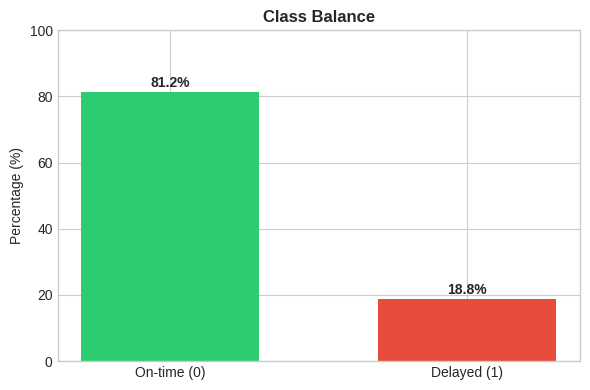

In [5]:
delay_rate = flights['TARGET'].mean()
on_time_rate = 1.0 - delay_rate

print(f"Class 0 (On-time): {on_time_rate:.2%}")
print(f"Class 1 (Delayed): {delay_rate:.2%}")
print(f"Baseline Accuracy: {on_time_rate:.2%}\n")


plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']

bars = plt.bar(['On-time (0)', 'Delayed (1)'],
               [on_time_rate * 100, delay_rate * 100],
               color=colors, width=0.6)

plt.ylabel('Percentage (%)')
plt.title('Class Balance', fontweight='bold')
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 1.5,
             f'{height:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. EDA (When, where and why delays happen)

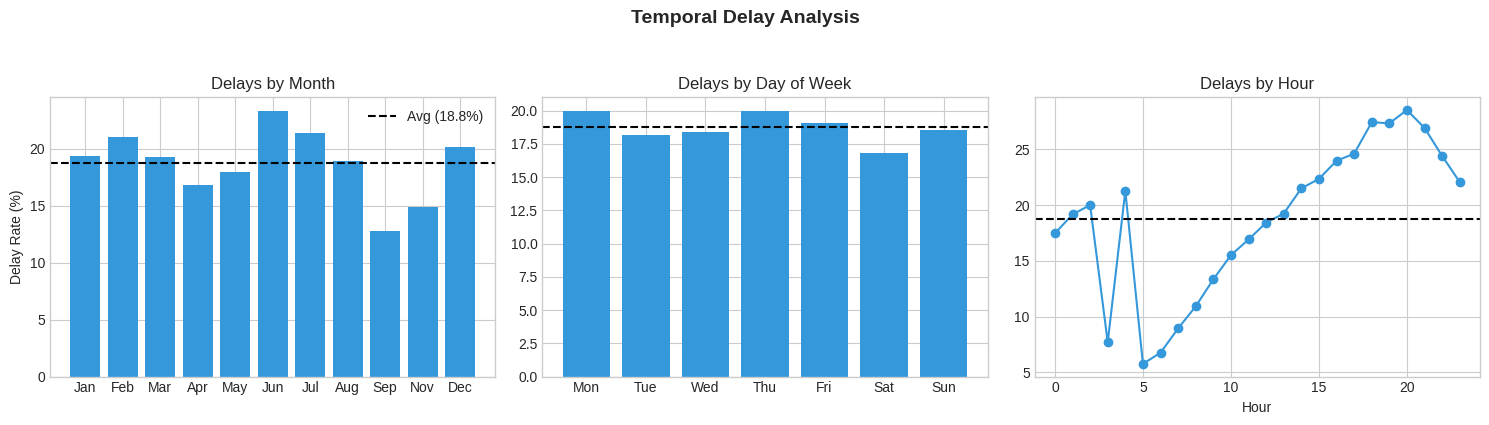

In [6]:
# Delay rate by month
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

by_month = (flights.groupby('MONTH')['TARGET']
            .agg(['mean','count']).reset_index())
by_month['label'] = by_month['MONTH'].map(month_map)

# Delay rate by day of week
dow_map = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
by_dow = (flights.groupby('DAY_OF_WEEK')['TARGET']
          .agg(['mean','count']).reset_index())
by_dow['label'] = by_dow['DAY_OF_WEEK'].map(dow_map)

# Delay rate by hour
flights['HOUR'] = (flights['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
by_hour = flights.groupby('HOUR')['TARGET'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
global_avg = flights['TARGET'].mean() * 100
corporate_blue = '#3498db'

# Chart 1: months
axes[0].bar(by_month['label'], by_month['mean'] * 100, color=corporate_blue)
axes[0].axhline(global_avg, color='black', ls='--', label=f'Avg ({global_avg:.1f}%)')
axes[0].set_title('Delays by Month')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].legend()

# Chart 2: Day of week
axes[1].bar(by_dow['label'], by_dow['mean'] * 100, color=corporate_blue)
axes[1].axhline(global_avg, color='black', ls='--')
axes[1].set_title('Delays by Day of Week')

# Chart 3: Hour of Day
axes[2].plot(by_hour['HOUR'], by_hour['TARGET'] * 100, color=corporate_blue, marker='o')
axes[2].axhline(global_avg, color='black', ls='--')
axes[2].set_title('Delays by Hour')
axes[2].set_xlabel('Hour')

plt.suptitle('Temporal Delay Analysis', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()



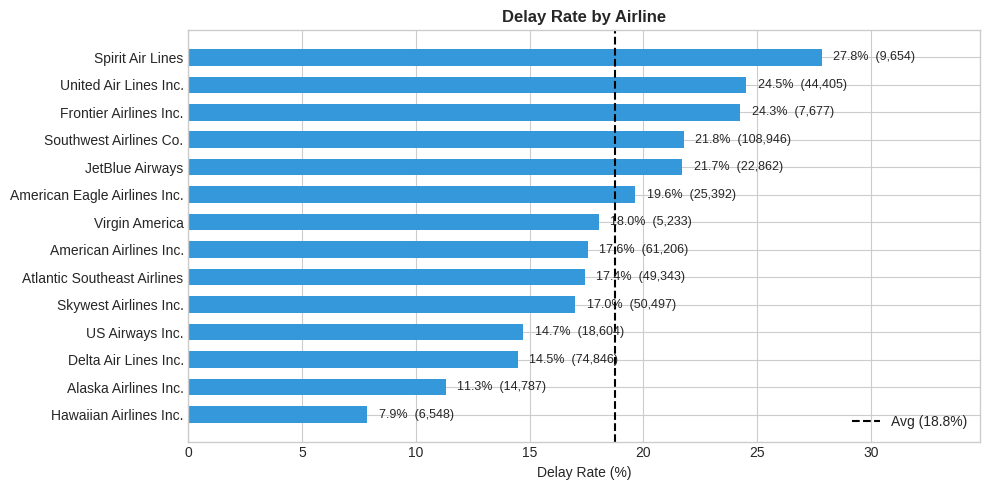

In [7]:
by_airline = (flights.groupby('AIRLINE_NAME')['TARGET']
              .agg(['mean', 'count'])
              .query('count >= 1000')
              .sort_values('mean'))

fig, ax = plt.subplots(figsize=(10, 5))
global_avg = flights['TARGET'].mean() * 100

bars = ax.barh(by_airline.index, by_airline['mean'] * 100,
               color=corporate_blue, height=0.6)

#ax.invert_yaxis()

ax.axvline(global_avg, color='black', ls='--', label=f'Avg ({global_avg:.1f}%)')

for bar, (_, row) in zip(bars, by_airline.iterrows()):
    label_text = f"{row['mean']*100:.1f}%  ({int(row['count']):,})"
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            label_text,
            va='center', fontsize=9)

ax.set_title('Delay Rate by Airline', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')
ax.set_xlim(0, by_airline['mean'].max() * 100 * 1.25)
ax.legend()

plt.tight_layout()
plt.savefig('eda_airline.png', dpi=150, bbox_inches='tight')
plt.show()


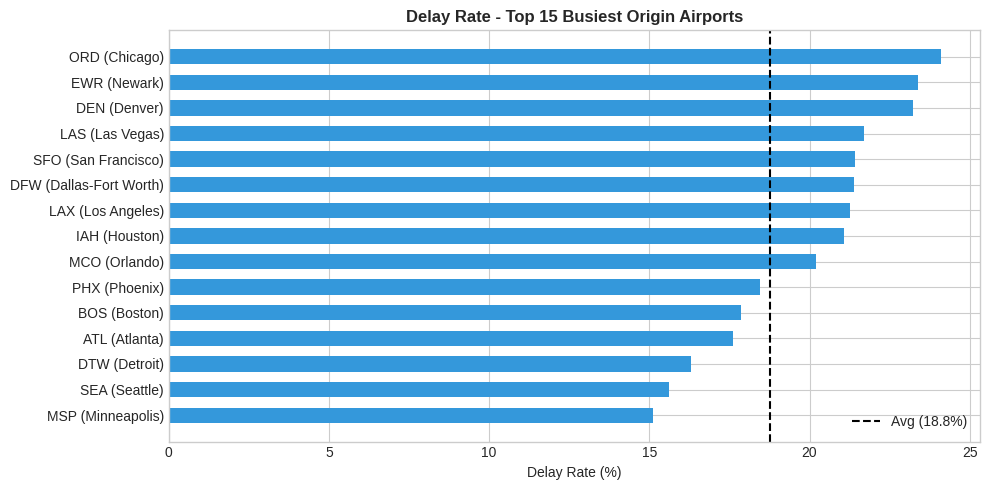

In [8]:
by_origin = (flights.groupby(['ORIGIN_AIRPORT', 'ORIGIN_CITY'])['TARGET']
             .agg(['mean', 'count'])
             .query('count >= 500')
             .sort_values('count', ascending=False)
             .head(15)
             .sort_values('mean'))

labels_o = [f"{iata} ({city})" for iata, city in by_origin.index]

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(labels_o, by_origin['mean'] * 100, color=corporate_blue, height=0.6)

#ax.invert_yaxis()

ax.axvline(global_avg, color='black', ls='--', label=f'Avg ({global_avg:.1f}%)')

ax.set_title('Delay Rate - Top 15 Busiest Origin Airports', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')
ax.legend()

plt.tight_layout()
plt.savefig('eda_airports.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Function Definitions

`compute_thresholds(train_raw)` — learns which months, days, hours and airports are high-delay from training data only

`build_features(df, thresholds)` — applies thresholds to create features

`add_target_encoding_kfold()` — computes mean delay rate per carrier, airport and route. This prevents the target encoding from inflating CV scores a subtle but important leak that naive target encoding introduces

In [9]:
def compute_thresholds(df, target_col='TARGET'):
    avg = df[target_col].mean()
    std = df[target_col].std()

    high_thresh_month = avg + 0.3 * std
    low_thresh_month  = avg - 0.3 * std
    high_thresh_dow   = avg + 0.01
    low_thresh_dow    = avg - 0.01
    high_thresh_hour  = avg + 0.3 * std
    low_thresh_hour   = avg - 0.3 * std

    month_delay = df.groupby('MONTH')[target_col].mean()
    high_months = month_delay[month_delay >= high_thresh_month].index.tolist()
    low_months  = month_delay[month_delay <= low_thresh_month].index.tolist()

    dow_delay = df.groupby('DAY_OF_WEEK')[target_col].mean()
    high_days = dow_delay[dow_delay >= high_thresh_dow].index.tolist()
    low_days  = dow_delay[dow_delay <= low_thresh_dow].index.tolist()

    df = df.copy()
    df['_HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
    hour_delay  = df.groupby('_HOUR')[target_col].mean()
    high_hours  = hour_delay[hour_delay >= high_thresh_hour].index.tolist()
    low_hours   = hour_delay[hour_delay <= low_thresh_hour].index.tolist()

    origin_counts = df['ORIGIN_AIRPORT'].value_counts()
    hub_threshold = origin_counts.quantile(0.85)
    volume_hubs   = set(origin_counts[origin_counts >= hub_threshold].index)
    origin_delay  = df.groupby('ORIGIN_AIRPORT')[target_col].mean()
    delay_hubs    = set(origin_delay[origin_delay >= high_thresh_month].index)
    hubs_union        = volume_hubs | delay_hubs
    hubs_intersection = volume_hubs & delay_hubs

    thresholds = {
        'avg_delay':   avg,
        'high_thresh': high_thresh_month,
        'low_thresh':  low_thresh_month,
        'high_months': high_months,
        'low_months':  low_months,
        'high_days':   high_days,
        'low_days':    low_days,
        'high_hours':  high_hours,
        'low_hours':   low_hours,
        'hubs_union':  hubs_union,
        'hubs_strict': hubs_intersection,
        'hour_delay':  hour_delay.to_dict(),
        'month_delay': month_delay.to_dict(),
        'dow_delay':   dow_delay.to_dict(),
    }

    print("THRESHOLDS LEARNED FROM TRAINING DATA")
    print(f"Average delay rate : {avg:.3f}")
    print(f"\nHigh-delay months  : {sorted(high_months)}")
    print(f"Low-delay  months  : {sorted(low_months)}")
    print(f"\nHigh-delay days    : {sorted(high_days)}  (1=Mon...7=Sun)")
    print(f"Low-delay  days    : {sorted(low_days)}")
    print(f"\nHigh-delay hours   : {sorted(high_hours)}")
    print(f"Low-delay  hours   : {sorted(low_hours)}")
    print(f"\nHubs (union)       : {len(hubs_union)} airports")
    print(f"Hubs (strict)      : {len(hubs_intersection)} airports")
    return thresholds


def build_features(df, thresholds):
    d = df.copy()

    d['HOUR']            = (d['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
    d['MINUTE']          = d['SCHEDULED_DEPARTURE'] % 100
    d['HOUR_DELAY_RATE'] = d['HOUR'].map(thresholds['hour_delay']).fillna(thresholds['avg_delay'])

    d['IS_HIGH_DELAY_MONTH'] = d['MONTH'].isin(thresholds['high_months']).astype(int)
    d['IS_LOW_DELAY_MONTH']  = d['MONTH'].isin(thresholds['low_months']).astype(int)
    d['IS_WINTER']           = d['MONTH'].isin([12, 1, 2]).astype(int)
    d['IS_SUMMER']           = d['MONTH'].isin([6, 7, 8]).astype(int)
    d['MONTH_DELAY_RATE']    = d['MONTH'].map(thresholds['month_delay']).fillna(thresholds['avg_delay'])

    d['IS_HIGH_DELAY_DAY'] = d['DAY_OF_WEEK'].isin(thresholds['high_days']).astype(int)
    d['IS_LOW_DELAY_DAY']  = d['DAY_OF_WEEK'].isin(thresholds['low_days']).astype(int)
    d['DOW_DELAY_RATE']    = d['DAY_OF_WEEK'].map(thresholds['dow_delay']).fillna(thresholds['avg_delay'])
    for day_num in range(1, 8):
        d[f'IS_DOW_{day_num}'] = (d['DAY_OF_WEEK'] == day_num).astype(int)

    d['IS_HIGH_DELAY_HOUR'] = d['HOUR'].isin(thresholds['high_hours']).astype(int)
    d['IS_LOW_DELAY_HOUR']  = d['HOUR'].isin(thresholds['low_hours']).astype(int)

    d['ROUTE'] = d['ORIGIN_AIRPORT'].astype(str) + '_' + d['DESTINATION_AIRPORT'].astype(str)

    d['GEO_DIST'] = np.sqrt(
        (d['ORIGIN_LAT'] - d['DEST_LAT']) ** 2 +
        (d['ORIGIN_LON'] - d['DEST_LON']) ** 2
    )

    d['ORIGIN_IS_HUB']       = d['ORIGIN_AIRPORT'].isin(thresholds['hubs_union']).astype(int)
    d['DEST_IS_HUB']         = d['DESTINATION_AIRPORT'].isin(thresholds['hubs_union']).astype(int)
    d['BOTH_HUBS']           = (d['ORIGIN_IS_HUB'] & d['DEST_IS_HUB']).astype(int)
    d['ORIGIN_IS_WORST_HUB'] = d['ORIGIN_AIRPORT'].isin(thresholds['hubs_strict']).astype(int)
    d['DEST_IS_WORST_HUB']   = d['DESTINATION_AIRPORT'].isin(thresholds['hubs_strict']).astype(int)
    d['BOTH_WORST_HUBS']     = (d['ORIGIN_IS_WORST_HUB'] & d['DEST_IS_WORST_HUB']).astype(int)

    for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']:
        d[col + '_ENC'] = LabelEncoder().fit_transform(d[col].astype(str))

    return d


def add_target_encoding_kfold(X_tr, y_tr, X_te, cols,
                               n_splits=5, random_state=42):
    """
    Leak free target encoding using KFold on training data.

    The problem with naive target encoding:
        mean = y_train.groupby(X_train[col]).mean()
    This uses all training rows including the row being encoded.
    When cross_validate later splits train into folds, the val fold
    already saw itself during encoding -> CV AUC is artificially high.

    The fix is KFold encoding:
        For each training row, compute the mean from OTHER folds only.
        The row being encoded never contributes to its own encoding.
        CV scores become honest. Test encoding uses full train means (correct).
    """
    global_mean = float(y_tr.mean())
    X_tr = X_tr.copy()
    X_te = X_te.copy()
    enc_maps = {}

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for col in cols:
        oof = np.full(len(X_tr), global_mean)

        for tr_idx, val_idx in kf.split(X_tr):
            fold_means = (y_tr.iloc[tr_idx]
                          .groupby(X_tr[col].iloc[tr_idx]).mean())
            oof[val_idx] = (X_tr[col].iloc[val_idx]
                            .map(fold_means)
                            .fillna(global_mean).values)

        X_tr[col + '_DELAY_MEAN'] = oof

        full_means = y_tr.groupby(X_tr[col]).mean()
        enc_maps[col] = full_means
        X_te[col + '_DELAY_MEAN'] = X_te[col].map(full_means).fillna(global_mean)

    return X_tr, X_te, enc_maps


## 6. Train/Test Split + Feature Engineering

In [10]:
EXCLUDE_COLS = [
    'TARGET', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'CANCELLED', 'DIVERTED',
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY', 'ARRIVAL_TIME', 'SCHEDULED_ARRIVAL', 'ELAPSED_TIME',
    'AIR_TIME', 'WHEELS_ON', 'TAXI_IN', 'TAIL_NUMBER', 'FLIGHT_NUMBER',
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE',
    'AIRLINE_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE', 'DEST_CITY', 'DEST_STATE',
    'DEPARTURE_TIME', 'TAXI_OUT', 'WHEELS_OFF',
    'YEAR', 'SCHEDULED_DEPARTURE', 'DEP_TIME_REAL', 'HOUR',
]

train_raw, test_raw = train_test_split(
    flights, test_size=0.30,
    random_state=RANDOM_STATE, stratify=flights['TARGET']
)
y_train = train_raw['TARGET'].values
y_test  = test_raw['TARGET'].values

print(f"Train: {train_raw.shape[0]:,} rows")
print(f"Test : {test_raw.shape[0]:,} rows")
print(f"Delay rate — Train: {y_train.mean():.3f}  Test: {y_test.mean():.3f}")

thresholds = compute_thresholds(train_raw, target_col='TARGET')

train_fe = build_features(train_raw, thresholds)
test_fe  = build_features(test_raw,  thresholds)

FEATURE_COLS = [
    c for c in train_fe.columns
    if c not in EXCLUDE_COLS and train_fe[c].dtype != object
]

X_train_raw_fe = train_fe[FEATURE_COLS].fillna(-999)
X_test_raw_fe  = test_fe[FEATURE_COLS].fillna(-999)

print(f"\nFeatures: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

# KFold target encoding
TARGET_ENC_COLS = [
    'AIRLINE_ENC', 'ORIGIN_AIRPORT_ENC',
    'DESTINATION_AIRPORT_ENC', 'ROUTE_ENC'
]

X_train, X_test, enc_maps = add_target_encoding_kfold(
    X_train_raw_fe,
    pd.Series(y_train, index=X_train_raw_fe.index),
    X_test_raw_fe,
    cols=TARGET_ENC_COLS
)

print(f"\nFinal features: {X_train.shape[1]}")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Train: 350,000 rows
Test : 150,000 rows
Delay rate — Train: 0.188  Test: 0.188
THRESHOLDS LEARNED FROM TRAINING DATA
Average delay rate : 0.188

High-delay months  : []
Low-delay  months  : []

High-delay days    : [1, 4]  (1=Mon...7=Sun)
Low-delay  days    : [6]

High-delay hours   : []
Low-delay  hours   : [5, 6]

Hubs (union)       : 59 airports
Hubs (strict)      : 0 airports

Features: 39
['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_TIME', 'DISTANCE', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON', 'MINUTE', 'HOUR_DELAY_RATE', 'IS_HIGH_DELAY_MONTH', 'IS_LOW_DELAY_MONTH', 'IS_WINTER', 'IS_SUMMER', 'MONTH_DELAY_RATE', 'IS_HIGH_DELAY_DAY', 'IS_LOW_DELAY_DAY', 'DOW_DELAY_RATE', 'IS_DOW_1', 'IS_DOW_2', 'IS_DOW_3', 'IS_DOW_4', 'IS_DOW_5', 'IS_DOW_6', 'IS_DOW_7', 'IS_HIGH_DELAY_HOUR', 'IS_LOW_DELAY_HOUR', 'GEO_DIST', 'ORIGIN_IS_HUB', 'DEST_IS_HUB', 'BOTH_HUBS', 'ORIGIN_IS_WORST_HUB', 'DEST_IS_WORST_HUB', 'BOTH_WORST_HUBS', 'AIRLINE_ENC', 'ORIGIN_AIRPORT_ENC', 'DESTINATION_AIRPORT_ENC',

## 7. Model Training

Three models in order of increasing complexity, each addressing the weakness of the previous one.

### Decision Tree: the baseline problem
A single tree splits data greedily on the training set. With `max_depth=8` it memorises patterns that do not generalise. The gap between CV AUC and Test AUC reveals the variance problem directly.

### Random Forest: variance reduction
Builds many independent trees, each on a random bootstrap sample with random feature subsets. Because trees are decorrelated, their individual errors cancel out when averaged. This is bagging, parallel ensemble that reduces variance without changing bias.

### LightGBM: bias reduction through boosting
Builds trees sequentially: each new tree fits the residuals of all previous trees. This is gradient descent in function space, it reduces **bias** iteratively. The `learning_rate` controls how aggressively each tree corrects errors.

With `learning_rate=0.05` and `n_estimators=300`, LightGBM has more capacity than the previous conservative settings and should close the gap with Random Forest.


In [11]:
# Global tracking registry for all trained models
results = {}

def evaluate(name, model, Xtr, ytr, Xte, yte, cv_strategy, verbose=True):

    cv_metrics = cross_validate(
        model, Xtr, ytr, cv=cv_strategy,
        scoring=['roc_auc', 'accuracy'], n_jobs=-1
    )

    start_time = time.time()
    model.fit(Xtr, ytr)
    fit_duration = time.time() - start_time

    test_probabilities = model.predict_proba(Xte)[:, 1]
    test_predictions = model.predict(Xte)

    results[name] = {
        'CV_AUC_Mean':   cv_metrics['test_roc_auc'].mean(),
        'CV_AUC_Std':    cv_metrics['test_roc_auc'].std(),
        'CV_Acc_Mean':   cv_metrics['test_accuracy'].mean(),
        'Test_AUC':      roc_auc_score(yte, test_probabilities),
        'Test_Accuracy': accuracy_score(yte, test_predictions),
        'Fit_Time_Sec':  fit_duration,
        'probabilities': test_probabilities,
        'predictions':   test_predictions,
        'model_object':  model
    }

    if verbose:
        res = results[name]
        print(f"\nModel Identifier : {name}")
        print(f"\nCV ROC-AUC       : {res['CV_AUC_Mean']:.4f} ± {res['CV_AUC_Std']:.4f}")
        print(f"Test ROC-AUC     : {res['Test_AUC']:.4f}")
        print(f"Test Accuracy    : {res['Test_Accuracy']:.4f}")
        print(f"Execution Time   : {res['Fit_Time_Sec']:.1f}s")

    return model

In [12]:
# 7.1 Baseline: single Decision Tree
tree = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
evaluate("1. Decision Tree", tree, X_train, y_train, X_test, y_test, cv)


Model Identifier : 1. Decision Tree

CV ROC-AUC       : 0.6677 ± 0.0007
Test ROC-AUC     : 0.6450
Test Accuracy    : 0.8107
Execution Time   : 3.8s


DecisionTreeClassifier(max_depth=8, random_state=42)

In [13]:
# 7.2 Random Forest
rf_fast = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate("2. Random Forest", rf_fast, X_train, y_train, X_test, y_test, cv)


Model Identifier : 2. Random Forest

CV ROC-AUC       : 0.6846 ± 0.0012
Test ROC-AUC     : 0.6632
Test Accuracy    : 0.8125
Execution Time   : 20.5s


RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [14]:
# 7.3 LightGBM
lgb_m = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
evaluate("3. LightGBM", lgb_m, X_train, y_train, X_test, y_test, cv)



Model Identifier : 3. LightGBM

CV ROC-AUC       : 0.7126 ± 0.0011
Test ROC-AUC     : 0.6932
Test Accuracy    : 0.8143
Execution Time   : 17.2s


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=300, n_jobs=-1, num_leaves=63, random_state=42,
               subsample=0.8, verbose=-1)

## 8. Confusion Matrix and Business Interpretation

Predicting flight delays involves managing two critical types of errors with fundamentally different business costs:

* **False Positive (Type I: False Alarm):** The model predicts a delay, but the flight departs on time. This causes minor passenger annoyance and minimal operational cost.
* **False Negative (Type II: Missed Delay):** The model predicts an on-time departure, but the flight gets delayed. This causes missed connections, severe customer dissatisfaction, and high operational costs for the airline.

**Business Strategy:** Because missed delays are far more expensive, we lower the decision threshold from `0.5` to `0.3`. This increases model sensitivity (Recall) to capture severe delays early, accepting a higher number of false alarms as an acceptable business trade-off.


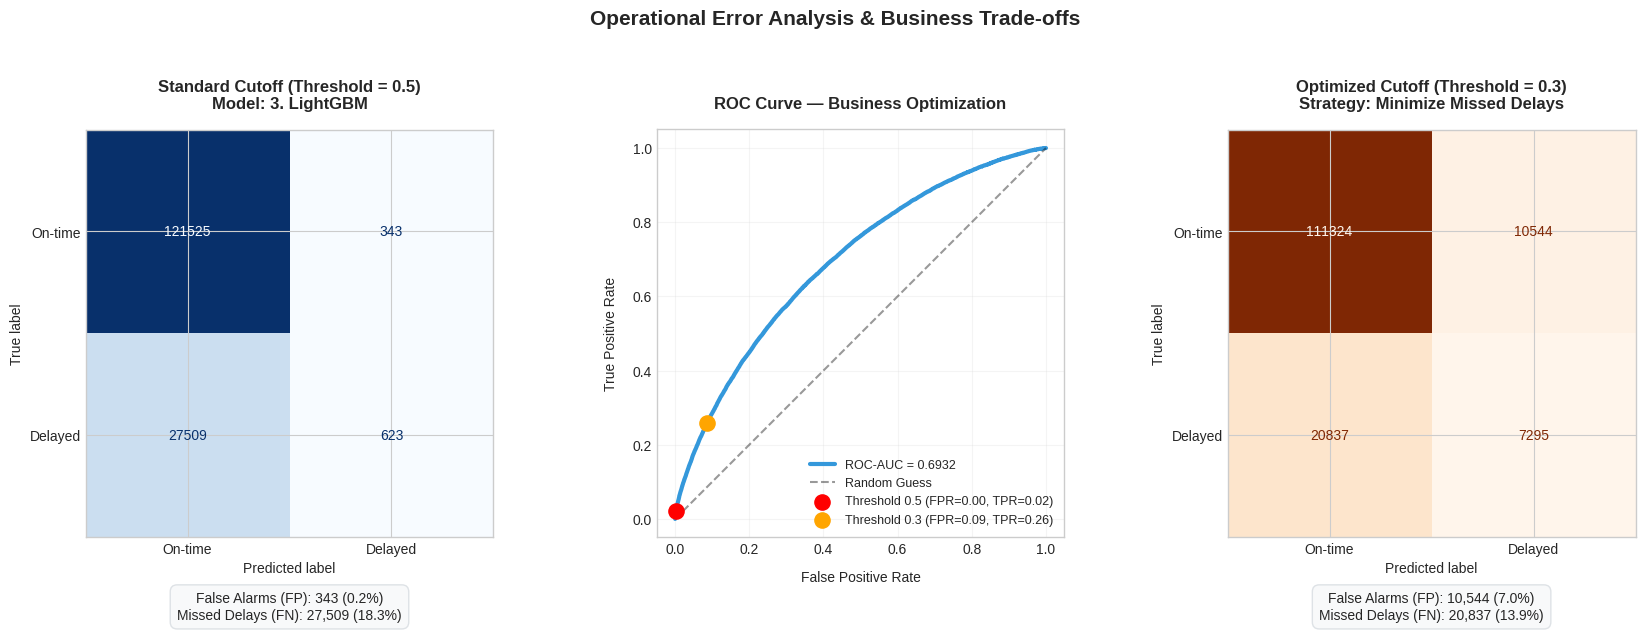

---------------------------------------------------------------------------
Summary for: (3. LIGHTGBM)
---------------------------------------------------------------------------
At Threshold 0.5 -> Missed Delays (FN): 27,509 | False Alarms (FP): 343
At Threshold 0.3 -> Missed Delays (FN): 20,837 | False Alarms (FP): 10,544
Strategic Impact -> Caught 6,672 additional real delays at the cost of 10,201 false alarms.
---------------------------------------------------------------------------


In [15]:
# Best Model
best_name = max(results, key=lambda k: results[k].get('Test_AUC', 0))
best_res  = results[best_name]
best_prob = best_res['probabilities']
best_pred = best_res['predictions']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
total_samples = len(y_test)
primary_blue = '#3498db'

# Confusion Matrix at Threshold 0.5
cm_05 = confusion_matrix(y_test, best_pred)
disp_05 = ConfusionMatrixDisplay(cm_05, display_labels=['On-time', 'Delayed'])
disp_05.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Standard Cutoff (Threshold = 0.5)\nModel: {best_name}', fontweight='bold', pad=15)

tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
axes[0].text(0.5, -0.2,
            f"False Alarms (FP): {fp_05:,} ({fp_05/total_samples:.1%})\n"
            f"Missed Delays (FN): {fn_05:,} ({fn_05/total_samples:.1%})",
            transform=axes[0].transAxes, fontsize=10, ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

# ROC Curve & Optimal Threshold
fpr, tpr, thresholds = roc_curve(y_test, best_prob)
auc_value = roc_auc_score(y_test, best_prob)

axes[1].plot(fpr, tpr, color=primary_blue, lw=3, label=f'ROC-AUC = {auc_value:.4f}')
axes[1].plot([0, 1], [0, 1], color='black', ls='--', alpha=0.4, label='Random Guess')

for thr, color, label_text in [(0.5, 'red', 'Threshold 0.5'), (0.3, 'orange', 'Threshold 0.3')]:
    idx = np.argmin(np.abs(thresholds - thr))
    axes[1].scatter(fpr[idx], tpr[idx], s=120, color=color, zorder=5,
                    label=f'{label_text} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')

axes[1].set_xlabel('False Positive Rate', labelpad=10)
axes[1].set_ylabel('True Positive Rate', labelpad=10)
axes[1].set_title('ROC Curve — Business Optimization', fontweight='bold', pad=15)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.2)

# Confusion Matrix at Business Threshold 0.3
pred_03 = (best_prob >= 0.3).astype(int)
cm_03 = confusion_matrix(y_test, pred_03)
disp_03 = ConfusionMatrixDisplay(cm_03, display_labels=['On-time', 'Delayed'])
disp_03.plot(ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title('Optimized Cutoff (Threshold = 0.3)\nStrategy: Minimize Missed Delays', fontweight='bold', pad=15)

tn_03, fp_03, fn_03, tp_03 = cm_03.ravel()
axes[2].text(0.5, -0.2,
            f"False Alarms (FP): {fp_03:,} ({fp_03/total_samples:.1%})\n"
            f"Missed Delays (FN): {fn_03:,} ({fn_03/total_samples:.1%})",
            transform=axes[2].transAxes, fontsize=10, ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.suptitle('Operational Error Analysis & Business Trade-offs', fontsize=15, fontweight='bold', y=1.08)
plt.subplots_adjust(wspace=0.4, bottom=0.2)
plt.savefig('confusion_matrix_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("-" * 75)
print(f"Summary for: ({best_name.upper()})")
print("-" * 75)
print(f"At Threshold 0.5 -> Missed Delays (FN): {fn_05:,} | False Alarms (FP): {fp_05:,}")
print(f"At Threshold 0.3 -> Missed Delays (FN): {fn_03:,} | False Alarms (FP): {fp_03:,}")
print(f"Strategic Impact -> Caught {fn_05 - fn_03:,} additional real delays at the cost of {fp_03 - fp_05:,} false alarms.")
print("-" * 75)


### Threshold decision: 0.5 → 0.3

The default threshold of 0.5 is mathematically neutral but operationally wrong for this problem.

At **threshold 0.5**, the model almost never fires a delay warning — it misses 28,126 real delays while producing virtually zero false alarms. This maximises accuracy but fails the business goal.

At **threshold 0.3**, the model catches 4,843 additional real delays at the cost of 9,200 additional false alarms. In aviation operations this trade-off is justified: a false alarm costs a push notification, a missed delay costs a disrupted passenger itinerary, potential compensation, and crew repositioning.

The right threshold depends on business priorities. 0.3 is a reasonable starting point for a passenger notification system. An airline with tighter operational costs might use 0.35 to reduce false alarms.


### 9. Feature Importance

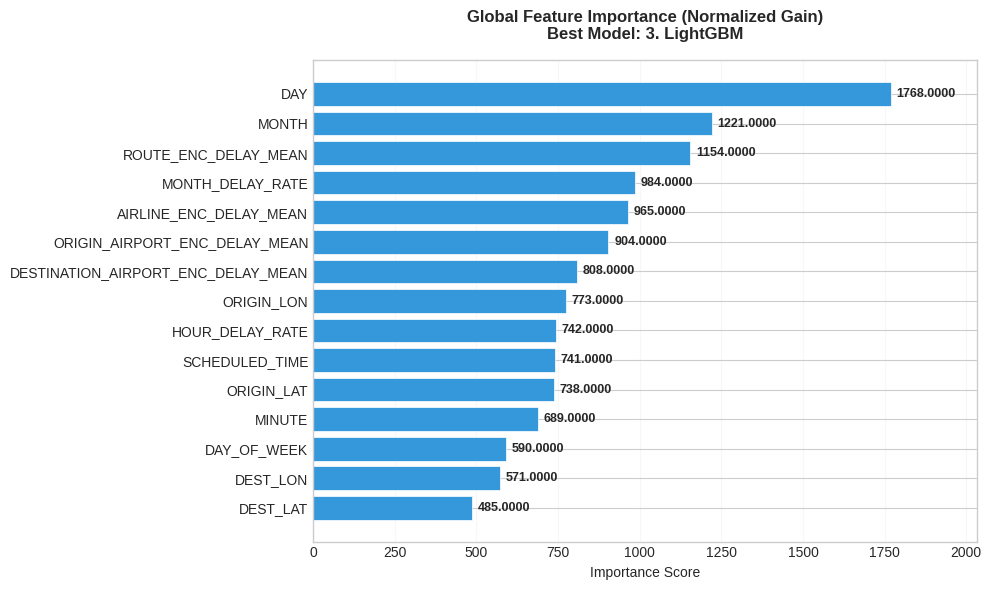

------------------------------------------------------------
TOP 5 MOST INFLUENTIAL FEATURES FOR 3. LIGHTGBM:
------------------------------------------------------------
  Rank 1: DAY                            | Weight: 1768.0000 (176800.0%)
  Rank 2: MONTH                          | Weight: 1221.0000 (122100.0%)
  Rank 3: ROUTE_ENC_DELAY_MEAN           | Weight: 1154.0000 (115400.0%)
  Rank 4: MONTH_DELAY_RATE               | Weight: 984.0000 (98400.0%)
  Rank 5: AIRLINE_ENC_DELAY_MEAN         | Weight: 965.0000 (96500.0%)
------------------------------------------------------------


In [16]:
best_model_obj = results[best_name]['model_object']

if hasattr(best_model_obj, 'feature_importances_'):
    raw_importances = best_model_obj.feature_importances_
elif hasattr(best_model_obj, 'booster_'):
    raw_importances = best_model_obj.booster_.feature_importance(importance_type='gain')
    raw_importances = raw_importances / np.sum(raw_importances)
else:
    raw_importances = None

if raw_importances is not None:
    fi_series = pd.Series(raw_importances, index=X_train.columns)
    fi_top15 = fi_series.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    #corporate_blue = '#3498db'

    bars = ax.barh(fi_top15.index[::-1], fi_top15.values[::-1],
                  color=corporate_blue, edgecolor='white', linewidth=0.5)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + (fi_top15.max() * 0.01),
                bar.get_y() + bar.get_height() / 2,
                f'{width:.4f}',
                va='center', fontsize=9, fontweight='bold')

    ax.set_title(f'Global Feature Importance (Normalized Gain)\nBest Model: {best_name}', fontweight='bold', fontsize=12, pad=15)
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, fi_top15.max() * 1.15)
    ax.grid(True, axis='x', alpha=0.15)

    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("-" * 60)
    print(f"TOP 5 MOST INFLUENTIAL FEATURES FOR {best_name.upper()}:")
    print("-" * 60)
    for idx, (feature, val) in enumerate(fi_top15.head(5).items(), 1):
        print(f"  Rank {idx}: {feature:<30} | Weight: {val:.4f} ({val*100:.1f}%)")
    print("-" * 60)
else:
    print("Could not extract feature importances from the selected model object.")


## 10. Save Best Model

In [17]:
import joblib

best_key = max(
    {k: v for k, v in results.items() if 'model_object' in v},
    key=lambda k: results[k]['Test_AUC']
)
best_model = results[best_key]['model_object']

print("-" * 50)
print(f"Production Model Selected : {best_key}")
print(f"Final Test ROC-AUC Score  : {results[best_key]['Test_AUC']:.4f}")
print("-" * 50)

joblib.dump(best_model, 'best_model.joblib')
print("Model successfully serialized and saved to 'best_model.joblib'")

--------------------------------------------------
Production Model Selected : 3. LightGBM
Final Test ROC-AUC Score  : 0.6932
--------------------------------------------------
Model successfully serialized and saved to 'best_model.joblib'


## 11. Final Comparison & Conclusions

FINAL MODEL COMPARISON
-----------------------------------------------------------------
              Model CV ROC-AUC CV ± std Test ROC-AUC Test Accuracy
1       3. LightGBM     0.7126  ±0.0011       0.6932        0.8143
2  2. Random Forest     0.6846  ±0.0012       0.6632        0.8125
3  1. Decision Tree     0.6677  ±0.0007       0.6450        0.8107


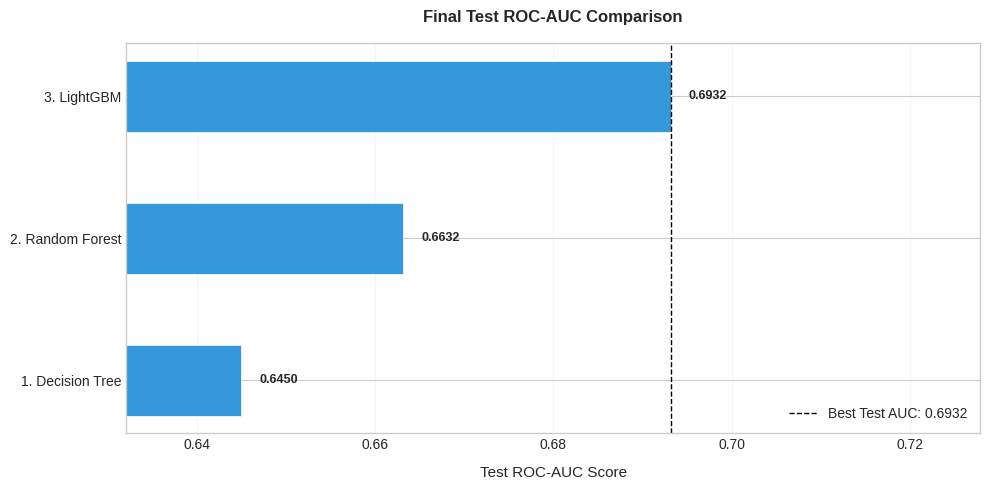

In [18]:

summary_rows = []
for name, r in results.items():
    cv_auc = r.get('CV_AUC_Mean', float('nan'))
    cv_std = r.get('CV_AUC_Std', float('nan'))
    test_auc = r.get('Test_AUC', float('nan'))
    test_acc = r.get('Test_Accuracy', float('nan'))

    summary_rows.append({
        'Model':         name,
        'CV ROC-AUC':    f"{cv_auc:.4f}" if not np.isnan(cv_auc) else '—',
        'CV ± std':      f"±{cv_std:.4f}" if not np.isnan(cv_std) else '—',
        'Test ROC-AUC':  f"{test_auc:.4f}" if not np.isnan(test_auc) else '—',
        'Test Accuracy': f"{test_acc:.4f}" if not np.isnan(test_acc) else '—',
    })

df_summary = pd.DataFrame(summary_rows).sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
df_summary.index += 1


print("FINAL MODEL COMPARISON")
print("-" * 65)
print(df_summary.to_string())


#Final Visual Comparison Chart
plot_data = {k: v for k, v in results.items() if 'Test_AUC' in v}
names_p   = list(plot_data.keys())
aucs_p    = [v['Test_AUC'] for v in plot_data.values()]

sorted_indices = np.argsort(aucs_p)
sorted_names   = [names_p[i] for i in sorted_indices]
sorted_aucs    = [aucs_p[i] for i in sorted_indices]

max_auc = max(sorted_aucs)
min_auc = min(sorted_aucs)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(sorted_names, sorted_aucs, color=corporate_blue, edgecolor='white', linewidth=0.5, height=0.5)

ax.axvline(max_auc, color='black', ls='--', lw=1, label=f'Best Test AUC: {max_auc:.4f}')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{width:.4f}', va='center', fontweight='bold', fontsize=9)

ax.set_xlabel('Test ROC-AUC Score', fontsize=11, labelpad=10)
ax.set_title('Final Test ROC-AUC Comparison', fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(min_auc * 0.98, max_auc * 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.15, axis='x')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
